[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/notebooks/EN/chapter11_lecture_notebook.ipynb)

# Time Series Analysis — Chapter 11: Foundation models for time series

*Lecture notebook (self-study chapter). Daniel Traian Pele, Bucharest University of Economic Studies.*

- A foundation model is pretrained once on many series and then forecasts a new series **zero-shot**, from its recent history only.
- We use small open models that run on a CPU: **Chronos-Bolt tiny** (9 million parameters), **Chronos-Bolt small** (48 million) and **Chronos-2** (Amazon, Apache-2.0 licence), through the `chronos-forecasting` package. No paid API.
- We compare them honestly with the seasonal naive forecast, ETS and ARIMA on Romanian and other series, with point (MASE) and probabilistic scores (weighted quantile loss, a CRPS approximation; coverage of the 80% interval).
- The first code cell installs `chronos-forecasting` if it is missing. If the installation or the model download fails, the foundation models are skipped and the rest of the notebook still runs.
- References: Ansari et al. (2024) Chronos, arXiv:2403.07815; Das et al. (2024) TimesFM, arXiv:2310.10688; Woo et al. (2024) Moirai, arXiv:2402.02592; Rasul et al. (2023) Lag-Llama, arXiv:2310.08278; Aksu et al. (2024) GIFT-Eval, arXiv:2410.10393; Gneiting and Raftery (2007), doi:10.1198/016214506000001437; Hyndman and Koehler (2006), doi:10.1016/j.ijforecast.2006.03.001.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_11'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/notebooks/EN


In [2]:
# Chronos models need the chronos-forecasting package (it installs PyTorch on a CPU-only machine if missing).
# If the installation or the model download fails, the foundation models are skipped and the
# statistical benchmarks (seasonal naive, ETS, ARIMA) still run.
import importlib.util, subprocess, sys
if importlib.util.find_spec('chronos') is None:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'chronos-forecasting'])
    except Exception as e:
        print('chronos-forecasting could not be installed:', e)

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Definitions and helpers used in the whole notebook

- `get_series(key)`: the seven evaluation series (`load`, `ip`, `gdp`, `infl`, `unemp`, `eurron`, `retail`).
- `chronos_pipeline(name)`: loads a Chronos model from Hugging Face (or returns `None`: graceful fallback).
- `fm_quantiles(name, contexts, h)`: zero-shot quantiles at the levels 0.1, ..., 0.9.
- `snaive_q`, `ets_q`, `arima_q`: the statistical benchmarks, with Normal quantiles.
- `pinball`, `wql_parts`, `mase`, `crps_normal`: the scores; `backtest(key, max_origins)`: rolling-origin evaluation.

In [6]:
import time
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.statespace.sarimax import SARIMAX
SEED = 2026
LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
FM = {'Chronos-Bolt tiny': 'amazon/chronos-bolt-tiny', 'Chronos-Bolt small': 'amazon/chronos-bolt-small', 'Chronos-2': 'amazon/chronos-2'}
RELEASE = {'Chronos-Bolt tiny': '2024-11-25', 'Chronos-Bolt small': '2024-11-25', 'Chronos-2': '2025-10-30'}
MODELS = ['Seasonal naive', 'ETS', 'ARIMA', 'Chronos-Bolt tiny', 'Chronos-Bolt small', 'Chronos-2']
LOAD_FILE = 'ch4_ro_load_hourly.csv'
LOAD_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/Quantlets/Ch_04/ch4_ro_load_hourly.csv'
EVAL_SERIES = {'load': ('RO electricity load, hourly', 168, 48, '2025-07-07', 168, 2048), 'ip': ('RO industrial production, monthly', 12, 12, '2016-01-01', 1, 2048), 'gdp': ('RO real GDP, quarterly', 4, 4, '2012-01-01', 1, 2048), 'infl': ('RO inflation, monthly', 12, 12, '2016-01-01', 1, 2048), 'unemp': ('RO unemployment rate, monthly', 1, 12, '2016-01-01', 1, 2048), 'eurron': ('EUR/RON, daily', 1, 20, '2016-01-04', 20, 2048), 'retail': ('US retail sales, monthly', 12, 12, '2016-01-01', 1, 2048)}
SHORT = {'load': 'RO load', 'ip': 'RO ind. prod.', 'gdp': 'RO GDP', 'infl': 'RO inflation', 'unemp': 'RO unemployment', 'eurron': 'EUR/RON', 'retail': 'US retail'}
CONTEXTS = [96, 192, 336, 672, 1344, 2048]
_PIPES = {}
COLORS = {'Seasonal naive': st.Amber, 'ETS': st.Forest, 'ARIMA': st.Purple, 'Chronos-Bolt tiny': st.Teal, 'Chronos-Bolt small': st.MainBlue, 'Chronos-2': st.IDAred, 'actual': st.DarkText}
HERE = "."


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def ro_load():
    """Hourly electricity load of Romania (GW), ENTSO-E extract of Chapter 4, Romanian winter time (UTC+2);
    isolated one-hour glitches (more than 30% away from both neighbours) are interpolated."""
    s = None
    local = [os.path.join(HERE, '..', 'Ch_04', LOAD_FILE)] + [os.path.join(d, 'Quantlets', 'Ch_04', LOAD_FILE)
                                                            for d in ('.', '..', '../..', '../../..')]
    for src in [p for p in local if os.path.exists(p)] + [LOAD_RAW]:
        try:
            s = pd.read_csv(src, index_col=0, parse_dates=True).iloc[:, 0]
            break
        except Exception:
            continue
    s.index = s.index + pd.Timedelta(hours=2)
    s = s.reindex(pd.date_range(s.index[0], s.index[-1], freq='h'))
    r = s / ((s.shift(1) + s.shift(-1)) / 2)
    s[(r < 0.7) | (r > 1.3)] = np.nan
    return (s.interpolate() / 1000).rename('load')


def get_series(key):
    """The seven evaluation series (levels, as published)."""
    if key == 'load':
        return ro_load()
    if key == 'ip':      # industrial production (mining, manufacturing, energy), 2021 = 100, not seasonally adjusted
        return read_eurostat('sts_inpr_m', 'M.PRD.B-D.NSA.I21.RO').rename('ip')
    if key == 'gdp':     # real GDP, chain-linked volumes 2010, million EUR, not seasonally adjusted
        return (read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO') / 1000).rename('gdp')
    if key == 'infl':    # monthly inflation, 100 * log change of the HICP, in %
        p = read_eurostat('prc_hicp_minr', 'M.I15.TOTAL.RO')
        return (100 * np.log(p).diff()).dropna().loc['2000':].rename('infl')
    if key == 'unemp':   # unemployment rate, seasonally adjusted, % of the labour force
        return read_eurostat('une_rt_m', 'M.SA.TOTAL.PC_ACT.T.RO').rename('unemp')
    if key == 'eurron':  # BNR reference rate
        return load_close('eurron').rename('eurron')
    if key == 'retail':  # US retail sales excluding food services, not seasonally adjusted, billion USD
        return (read_fred('RSXFSN') / 1000).rename('retail')
    raise KeyError(key)


def chronos_pipeline(name):
    """Load a Chronos model from Hugging Face (cached); None if the package or the download is not available."""
    if name in _PIPES:
        return _PIPES[name]
    try:
        import torch
        from chronos import BaseChronosPipeline
        _PIPES[name] = BaseChronosPipeline.from_pretrained(FM[name], device_map='cpu', torch_dtype=torch.float32)
    except Exception as e:                       # graceful fallback: the statistical models still run
        print(f'   {name} not available ({type(e).__name__}): skipped')
        _PIPES[name] = None
    return _PIPES[name]


def fm_quantiles(name, contexts, h):
    """Zero-shot quantile forecasts (n, h, 9) at LEVELS from a list of 1-D context arrays; None if unavailable."""
    pipe = chronos_pipeline(name)
    if pipe is None:
        return None
    import torch
    x = [torch.tensor(np.asarray(c, dtype=np.float32)) for c in contexts]
    out = []
    for i in range(0, len(x), 64):
        q, _ = pipe.predict_quantiles(inputs=x[i:i + 64], prediction_length=h, quantile_levels=LEVELS)
        if isinstance(q, list):                   # Chronos-2 returns one tensor per series
            q = torch.stack([t.reshape(-1, h, len(LEVELS))[0] for t in q])
        out.append(q.float().numpy())
    return np.concatenate(out)


def n_parameters(name):
    pipe = chronos_pipeline(name)
    return None if pipe is None else int(sum(p.numel() for p in pipe.model.parameters()))


def normal_q(mean, sd):
    z = stats.norm.ppf(LEVELS)
    return np.asarray(mean)[:, None] + np.asarray(sd)[:, None] * z[None, :]


def snaive_q(y, h, m):
    """Seasonal naive: the value one season earlier; sd_h = sigma * sqrt(k + 1), k = number of whole seasons in h - 1
    (Hyndman and Athanasopoulos, FPP3, 5.5); sigma from the in-sample seasonal differences."""
    y = np.asarray(y, float)
    f = np.array([y[len(y) - m + (j % m)] for j in range(h)])
    e = y[m:] - y[:-m]
    sig = np.sqrt(np.mean(e ** 2))
    k = np.arange(h) // m
    return normal_q(f, sig * np.sqrt(k + 1))


def ets_q(y, h, m):
    """ETS with additive errors, damped additive trend and (if m > 1) additive seasonality; Normal quantiles."""
    y = pd.Series(np.asarray(y, float))
    seas = 'add' if 1 < m <= 52 else None
    r = ETSModel(y, error='add', trend='add', damped_trend=True, seasonal=seas,
                 seasonal_periods=m if seas else None).fit(disp=False, maxiter=200)
    p = r.get_prediction(start=len(y), end=len(y) + h - 1)
    return normal_q(np.asarray(p.predicted_mean), np.sqrt(np.asarray(p.forecast_variance)))


def select_arima(y, m):
    """Orders fixed once by AIC on the data before the first origin: (p, d, q) with p, q <= 2, d <= 1, and a seasonal
    MA(1) with one seasonal difference when 1 < m <= 52; for hourly load (m = 168) an ARMA on the weekly differences."""
    y = np.asarray(y, float)
    best = None
    for d in (0, 1):
        for p in range(3):
            for q in range(3):
                for D in ((0, 1) if 1 < m <= 52 else (0,)):
                    so = (0, D, 1, m) if D else (0, 0, 0, 0)
                    if m == 168:
                        so = (0, 1, 0, 168)
                        if d == 1:
                            continue
                    try:
                        a = SARIMAX(y, order=(p, d, q), seasonal_order=so, trend='c' if d + so[1] == 0 else 'n',
                                    simple_differencing=m == 168).fit(disp=False).aic
                    except Exception:
                        continue
                    if best is None or a < best[0]:
                        best = (a, (p, d, q), so)
    return best[1], best[2]


def arima_q(y, h, order, sorder):
    y = np.asarray(y, float)
    m = sorder[3]
    trend = 'c' if order[1] + sorder[1] == 0 else 'n'
    if m == 168:                                 # ARMA on y_t - y_{t-168}, then integrated back (h <= 168)
        r = SARIMAX(y, order=order, seasonal_order=sorder, trend=trend, simple_differencing=True).fit(disp=False)
        f = r.get_forecast(h)
        mean = y[len(y) - 168 + np.arange(h)] + np.asarray(f.predicted_mean)
        return normal_q(mean, np.sqrt(np.asarray(f.var_pred_mean)))
    r = SARIMAX(y, order=order, seasonal_order=sorder, trend=trend).fit(disp=False)
    f = r.get_forecast(h)
    return normal_q(np.asarray(f.predicted_mean), np.sqrt(np.asarray(f.var_pred_mean)))


def pinball(y, q, tau):
    """Quantile (pinball) loss: tau (y - q) if y >= q, (1 - tau)(q - y) otherwise."""
    u = np.asarray(y) - np.asarray(q)
    return np.maximum(tau * u, (tau - 1) * u)


def wql_parts(y, Q):
    """Numerator and denominator of the weighted quantile loss: sum over levels and steps of 2 * pinball, and
    sum |y| (times the number of levels). WQL = numerator / denominator, a discrete approximation of the CRPS."""
    num = sum(2 * pinball(y, Q[:, j], t).sum() for j, t in enumerate(LEVELS))
    return float(num), float(np.abs(y).sum() * len(LEVELS))


def mase(y, f, insample, m):
    """Mean absolute scaled error: MAE of the forecast over the in-sample MAE of the seasonal naive forecast."""
    x = np.asarray(insample, float)
    scale = np.mean(np.abs(x[m:] - x[:-m]))
    return float(np.mean(np.abs(np.asarray(y) - np.asarray(f))) / scale)


def crps_normal(y, mu, sigma):
    """Closed-form CRPS of N(mu, sigma^2) at y (Gneiting and Raftery 2007)."""
    z = (y - mu) / sigma
    return float(sigma * (z * (2 * stats.norm.cdf(z) - 1) + 2 * stats.norm.pdf(z) - 1 / np.sqrt(np.pi)))


def origins_of(key, s):
    label, m, h, first, step, C = EVAL_SERIES[key]
    pos = np.arange(s.index.get_indexer([s.index[s.index >= pd.Timestamp(first)][0]])[0], len(s) - h + 1, step)
    return [int(p) for p in pos]


def backtest(key, max_origins=None, models=None, keep=False):
    """Rolling-origin evaluation of one series: at each origin every model forecasts h steps from the data up to the
    origin (at most C observations). Rows: origin, model, MASE, WQL parts, coverage of the 80% interval."""
    models = models or MODELS
    label, m, h, first, step, C = EVAL_SERIES[key]
    s = get_series(key)
    pos = origins_of(key, s)
    if max_origins:
        pos = pos[-max_origins:]
    order, sorder = select_arima(s.values[max(0, pos[0] - C):pos[0]][-1500:], m) if 'ARIMA' in models else (None, None)
    ctx = [s.values[max(0, p - C):p] for p in pos]
    Q = {}
    times = {}
    for name in [k for k in models if k in FM]:
        t0 = time.time()
        Q[name] = fm_quantiles(name, ctx, h)
        times[name] = (time.time() - t0) / len(ctx)
    for name in [k for k in models if k not in FM]:
        t0 = time.time()
        out = []
        for c in ctx:
            try:
                if name == 'Seasonal naive':
                    out.append(snaive_q(c, h, m))
                elif name == 'ETS':
                    out.append(ets_q(c[-2016:] if m == 168 else c, h, 24 if m == 168 else m))
                else:
                    out.append(arima_q(c, h, order, sorder))
            except Exception:
                out.append(snaive_q(c, h, m))
        Q[name] = np.array(out)
        times[name] = (time.time() - t0) / len(ctx)
    rows, store = [], {}
    for name, q in Q.items():
        if q is None:
            continue
        for i, p in enumerate(pos):
            y = s.values[p:p + h]
            num, den = wql_parts(y, q[i])
            rows.append({'series': key, 'origin': s.index[p], 'model': name, 'mase': mase(y, q[i][:, 4], ctx[i], m),
                         'wql_num': num, 'wql_den': den, 'cov80': float(np.mean((y >= q[i][:, 0]) & (y <= q[i][:, 8]))),
                         'abs_err': list(np.abs(y - q[i][:, 4]))})
        store[name] = q
    df = pd.DataFrame(rows)
    info = {'order': order, 'sorder': sorder, 'n_origins': len(pos), 'first': str(s.index[pos[0]]),
            'last': str(s.index[pos[-1]]), 'seconds': times}
    return (df, info, store, s, pos) if keep else (df, info)


def summarise(df):
    """Per series: mean MASE, WQL (sum of numerators over sum of denominators), coverage; relative to seasonal naive."""
    g = df.groupby('model')
    out = pd.DataFrame({'mase': g['mase'].mean(), 'wql': g['wql_num'].sum() / g['wql_den'].sum(), 'cov80': g['cov80'].mean()})
    out['rel_mase'] = out['mase'] / out.loc['Seasonal naive', 'mase']
    out['rel_wql'] = out['wql'] / out.loc['Seasonal naive', 'wql']
    return out


def run_all(max_origins=None, save_csv=True):
    """Backtest of all seven series; returns the per-row results and the per-series summaries."""
    frames, infos = [], {}
    for key in EVAL_SERIES:
        print('   backtest', key)
        df, info = backtest(key, max_origins)
        frames.append(df)
        infos[key] = info
    allr = pd.concat(frames, ignore_index=True)
    if save_csv:
        allr.drop(columns='abs_err').to_csv(os.path.join(HERE, 'ch11_backtest.csv'), index=False)
        allr[['series', 'origin', 'model', 'abs_err']].to_json(os.path.join(HERE, 'ch11_abs_err.json'), orient='records', date_format='iso')
    return allr, infos


def load_results():
    p = os.path.join(HERE, 'ch11_backtest.csv')
    if not os.path.exists(p):
        return run_all()[0]
    df = pd.read_csv(p, parse_dates=['origin'])
    pe = os.path.join(HERE, 'ch11_abs_err.json')
    if not os.path.exists(pe):                   # errors by step are only needed for fig_horizon
        return df
    e = pd.read_json(pe, orient='records')
    e['origin'] = pd.to_datetime(e['origin']).dt.tz_localize(None)
    return df.merge(e, on=['series', 'origin', 'model'], how='left')

## 1. Is a foundation model available?

- Load Chronos-Bolt small once and count its parameters.

In [7]:
pipe = chronos_pipeline('Chronos-Bolt small')
print('Chronos-Bolt small loaded:', pipe is not None)
print({name: n_parameters(name) for name in FM})

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Chronos-Bolt small loaded: True


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

{'Chronos-Bolt tiny': 8652672, 'Chronos-Bolt small': 47718016, 'Chronos-2': 119477664}


## 2. Tokens, patches and scores

- Mean scaling and quantisation (Chronos); patching (PatchTST, TimesFM, Chronos-Bolt); the pinball loss and the CRPS.

scale s = 6.6 | scaled: [0.985, 1.03, 1.015, 1.03, 0.97, 0.97] | tokens: [2180, 2187, 2184, 2187, 2178, 2178]
attention weights: [0.665, 0.245, 0.09] | pinball losses: {0.1: 0.07000000000000002, 0.5: 0.10000000000000009, 0.9: 0.03999999999999994}


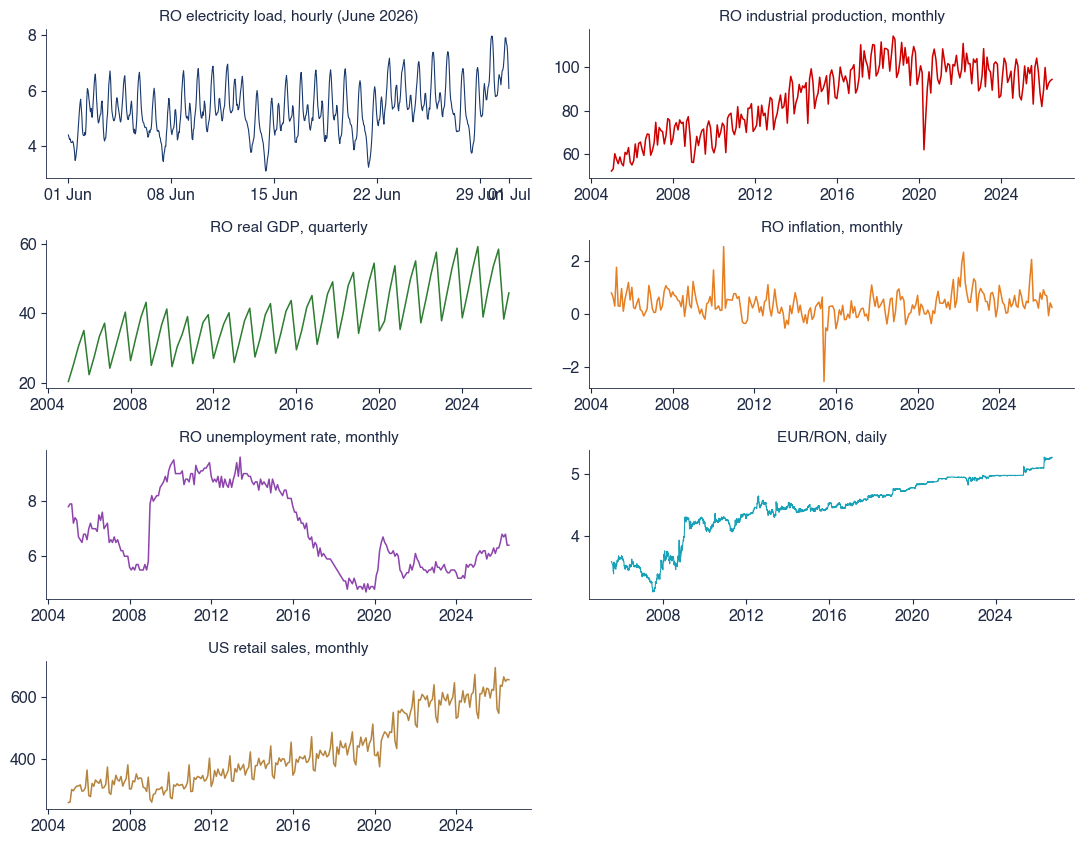

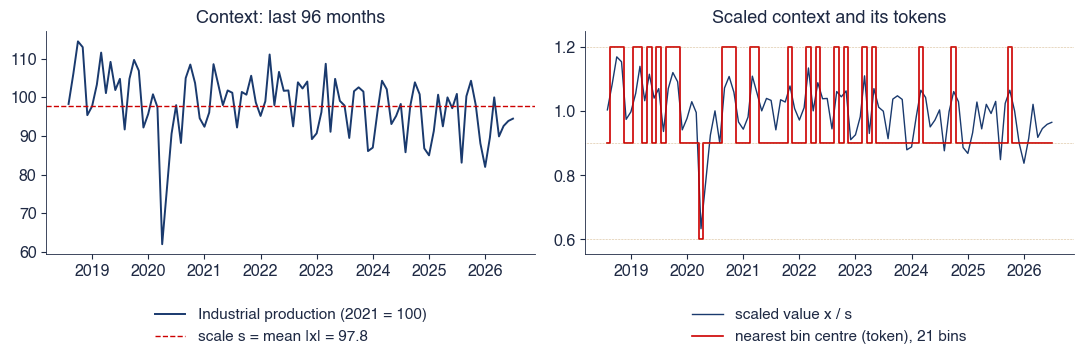

{'s': 97.84791666666666, 'zmin': 0.6336363829923137, 'zmax': 1.1701833202035472, 'ntok': 3, 'bins': 21, 'start': '2018-08-01', 'end': '2026-07-01'}


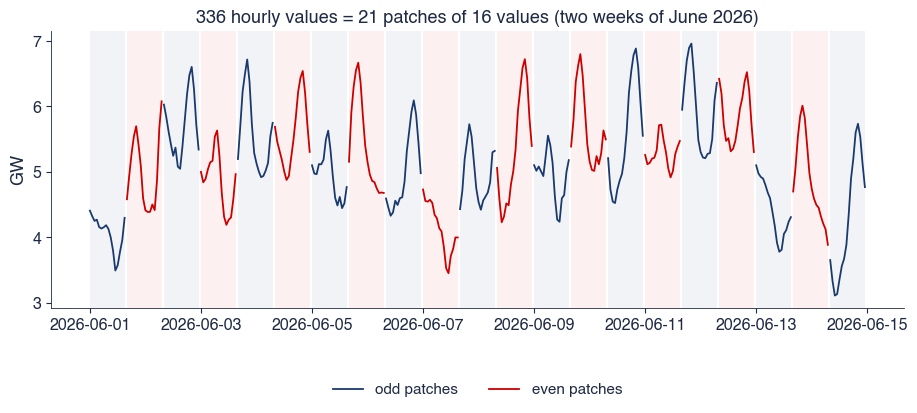

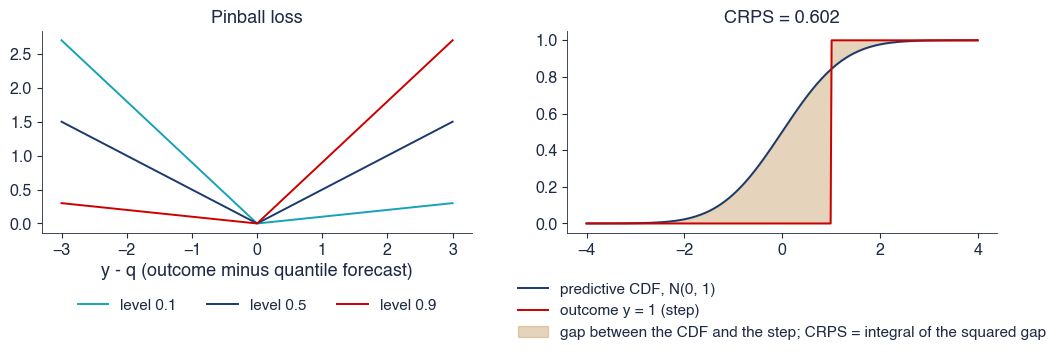

{'crps': 0.6024413576276163}

In [8]:
def worked_examples():
    """Numbers of the worked examples: mean scaling and tokens, the pinball loss, the Normal CRPS, MASE."""
    u = get_series('unemp').iloc[-6:]
    s = float(np.mean(np.abs(u.values)))
    centres = np.linspace(-15, 15, 4093)
    z = u.values / s
    tok = [int(np.argmin(np.abs(centres - v))) for v in z]
    y, q1, q5, q9 = 7.2, 6.5, 7.0, 7.6
    pl = {t: float(pinball(y, q, t)) for t, q in ((0.1, q1), (0.5, q5), (0.9, q9))}
    sc = np.array([2.0, 1.0, 0.0])                 # attention: scores q.k / sqrt(d) of one query against three keys
    w = np.exp(sc) / np.exp(sc).sum()
    vals = np.array([10.0, 20.0, 30.0])
    return {'att_w': [float(v) for v in w], 'att_out': float(w @ vals),
            'mase_mae': 0.3, 'mase_scale': 0.25, 'mase': 0.3 / 0.25,
            'cov_in': 7, 'cov_n': 10,
            'u_dates': [str(d.date()) for d in u.index], 'u': [float(v) for v in u.values], 's': s, 'z': [float(v) for v in z],
            'tok': tok, 'width': float(centres[1] - centres[0]), 'pin_y': y, 'pin_q': [q1, q5, q9], 'pin': pl,
            'crps_y': 1.0, 'crps': crps_normal(1.0, 0.0, 1.0), 'crps0': crps_normal(0.0, 0.0, 1.0),
            'crps_wide': crps_normal(1.0, 0.0, 2.0)}


def fig_series(save_it=True):
    """The seven evaluation series."""
    fig, axes = plt.subplots(4, 2, figsize=(11, 8.6))
    out = {}
    for ax, (k, col) in zip(axes.flat, zip(EVAL_SERIES, [st.MainBlue, st.IDAred, st.Forest, st.Orange, st.Purple, st.Teal, st.Amber])):
        s = get_series(k)
        x = s.loc['2026-06-01':'2026-06-30'] if k == 'load' else s.loc['2005':]
        ax.plot(x.index, x.values, color=col, lw=0.8 if k in ('load', 'eurron') else 1.1)
        ax.set_title(EVAL_SERIES[k][0] + (' (June 2026)' if k == 'load' else ''), fontsize=11)
        if k == 'load':
            import matplotlib.dates as mdates
            ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[1, 8, 15, 22, 29]))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        out[k] = {'n': int(len(s)), 'start': str(s.index[0].date()), 'end': str(s.index[-1].date())}
    axes.flat[-1].axis('off')
    fig.tight_layout()
    save('tsa_ch11_series', save_it)
    return out


def fig_tokens(save_it=True, bins=21):
    """Mean scaling and quantisation (Chronos) on Romanian industrial production; a coarse grid of `bins` bins in
    [-3, 3] instead of 4093 in [-15, 15], so that the steps are visible."""
    x = get_series('ip').iloc[-96:]
    s = float(np.mean(np.abs(x.values)))
    z = x.values / s
    grid = np.linspace(-3, 3, bins)
    tok = np.array([np.argmin(np.abs(grid - v)) for v in z])
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.9))
    a1.plot(x.index, x.values, color=st.MainBlue, label='Industrial production (2021 = 100)')
    a1.axhline(s, color=st.IDAred, ls='--', lw=1, label=f'scale s = mean |x| = {s:.1f}')
    a1.set_title('Context: last 96 months')
    st.legend_outside_bottom(a1, ncol=1, y=-0.18)
    a2.plot(x.index, z, color=st.MainBlue, lw=1, label='scaled value x / s')
    a2.step(x.index, grid[tok], where='mid', color=st.IDAred, lw=1.2, label=f'nearest bin centre (token), {bins} bins')
    for g in grid:
        if 0.5 < g < 1.5:
            a2.axhline(g, color=st.Amber, lw=0.4, ls=':')
    a2.set_ylim(min(z) - 0.08, max(z) + 0.08)
    a2.set_title('Scaled context and its tokens')
    st.legend_outside_bottom(a2, ncol=1, y=-0.18)
    fig.tight_layout()
    save('tsa_ch11_tokens', save_it)
    return {'s': s, 'zmin': float(z.min()), 'zmax': float(z.max()), 'ntok': int(len(set(tok))), 'bins': bins,
            'start': str(x.index[0].date()), 'end': str(x.index[-1].date())}


def fig_patching(save_it=True, P=16):
    """Patching: 336 hours of Romanian load cut into patches of P = 16 values; each patch becomes one input vector."""
    x = get_series('load').loc['2026-06-01':].iloc[:336]
    fig, ax = plt.subplots(figsize=(11, 3.6))
    cols = [st.MainBlue, st.IDAred]
    for i in range(0, len(x), P):
        seg = x.iloc[i:i + P]
        ax.plot(seg.index, seg.values, color=cols[(i // P) % 2], lw=1.3,
                label=('odd patches' if (i // P) % 2 == 0 else 'even patches') if i < 2 * P else '_')
        ax.axvspan(seg.index[0], seg.index[-1], color=cols[(i // P) % 2], alpha=0.06, lw=0)
    ax.set_ylabel('GW')
    ax.set_title(f'{len(x)} hourly values = {len(x) // P} patches of {P} values (two weeks of June 2026)')
    st.legend_outside_bottom(ax, ncol=2)
    save('tsa_ch11_patching', save_it)
    return {'n': int(len(x)), 'P': P, 'patches': int(len(x) // P)}


def fig_scores(save_it=True):
    """Left: the pinball loss at levels 0.1, 0.5, 0.9 as a function of y - q. Right: the CRPS of N(0, 1) at y = 1 as
    the area of the squared distance between the predictive CDF and the step function of the outcome."""
    u = np.linspace(-3, 3, 400)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.9))
    for t, c in ((0.1, st.Teal), (0.5, st.MainBlue), (0.9, st.IDAred)):
        a1.plot(u, pinball(u, 0, t), color=c, label=f'level {t}')
    a1.set_xlabel('y - q (outcome minus quantile forecast)')
    a1.set_title('Pinball loss')
    st.legend_outside_bottom(a1, ncol=3, y=-0.26)
    z = np.linspace(-4, 4, 400)
    F = stats.norm.cdf(z)
    H = (z >= 1).astype(float)
    a2.plot(z, F, color=st.MainBlue, label='predictive CDF, N(0, 1)')
    a2.plot(z, H, color=st.IDAred, label='outcome y = 1 (step)')
    a2.fill_between(z, F, H, color=st.Amber, alpha=0.35, label='gap between the CDF and the step; CRPS = integral of the squared gap')
    a2.set_title(f'CRPS = {crps_normal(1.0, 0.0, 1.0):.3f}')
    st.legend_outside_bottom(a2, ncol=1, y=-0.18)
    fig.tight_layout()
    save('tsa_ch11_scores', save_it)
    return {'crps': crps_normal(1.0, 0.0, 1.0)}


ex = worked_examples()
print('scale s =', round(ex['s'], 3), '| scaled:', [round(z, 3) for z in ex['z']], '| tokens:', ex['tok'])
print('attention weights:', [round(w, 3) for w in ex['att_w']], '| pinball losses:', ex['pin'])
fig_series(save_it=False)
print(fig_tokens(save_it=False))
fig_patching(save_it=False)
fig_scores(save_it=False)

## 3. Zero-shot forecasts

- Romanian load (48 hours), Romanian industrial production (12 months), EUR/RON (20 days).

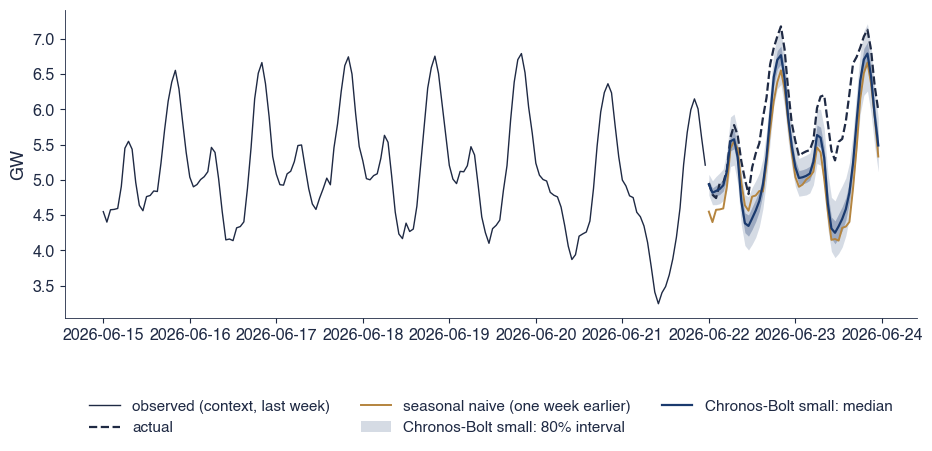

{'origin': '2026-06-22', 'mase_naive': 1.6112746265520017, 'mase_bolt': 1.311000041872773, 'cov_bolt': 0.2916666666666667, 'q_24': [5.183659553527832, 5.4763288497924805, 5.775794506072998], 'y_24': 5.80325, 't_24': '2026-06-22 23:00:00', 'pin_24': {'0.1': 0.06195904464721683, '0.5': 0.1634605751037599, '0.9': 0.024709944534301975}}


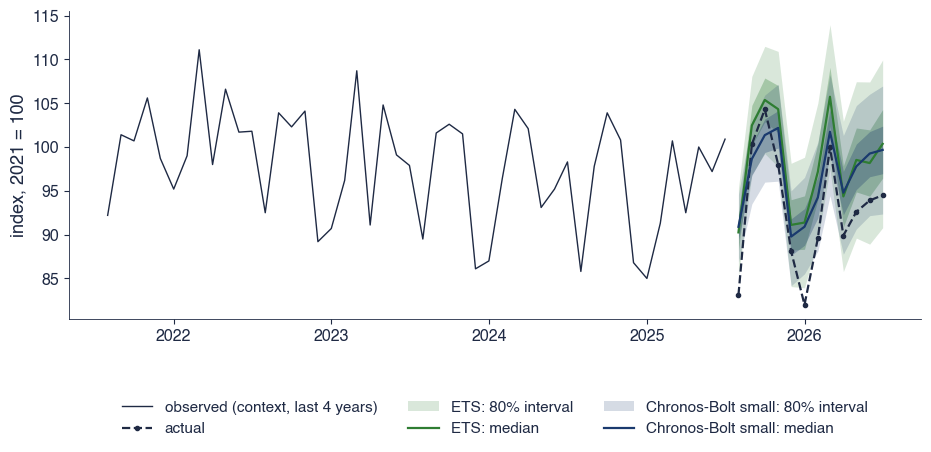

{'origin': '2025-08-01', 'end': '2026-07-01', 'mase_ets': 1.2044880325572693, 'cov_ets': 0.8333333333333334, 'mase_bolt': 1.0364551705053164, 'cov_bolt': 0.8333333333333334, 'mase_naive': 0.6660179057999221}


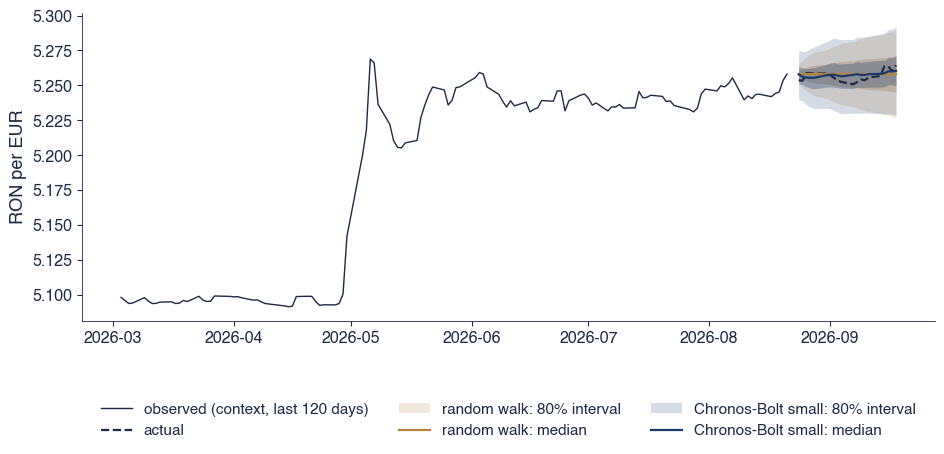

{'origin': '2026-08-24', 'end': '2026-09-18', 'last': 5.2581, 'width_rw': 0.06273003554847989, 'med_bolt': 5.260365962982178, 'width_bolt': 0.06351280212402344, 'mae_bolt': 0.003197094650268584, 'mae_rw': 0.003475000000000028}


In [9]:
def fan(ax, idx, Q, color, label):
    ax.fill_between(idx, Q[:, 0], Q[:, 8], color=color, alpha=0.18, lw=0, label=f'{label}: 80% interval')
    ax.fill_between(idx, Q[:, 2], Q[:, 6], color=color, alpha=0.30, lw=0, label='_')
    ax.plot(idx, Q[:, 4], color=color, lw=1.6, label=f'{label}: median')


def fig_fan_load(save_it=True, origin='2026-06-22'):
    """48-hour zero-shot forecast of Romanian load (Chronos-Bolt small, 2048-hour context) against the seasonal naive."""
    s = get_series('load')
    p = s.index.get_loc(pd.Timestamp(origin))
    ctx = s.values[p - 2048:p]
    h = 48
    idx = s.index[p:p + h]
    Qb = fm_quantiles('Chronos-Bolt small', [ctx], h)
    Qn = snaive_q(ctx, h, 168)
    fig, ax = plt.subplots(figsize=(11, 4))
    hist = s.iloc[p - 168:p]
    ax.plot(hist.index, hist.values, color=st.DarkText, lw=1, label='observed (context, last week)')
    ax.plot(idx, s.values[p:p + h], color=st.DarkText, lw=1.6, ls='--', label='actual')
    ax.plot(idx, Qn[:, 4], color=COLORS['Seasonal naive'], lw=1.4, label='seasonal naive (one week earlier)')
    out = {'origin': origin, 'mase_naive': mase(s.values[p:p + h], Qn[:, 4], ctx, 168)}
    if Qb is not None:
        fan(ax, idx, Qb[0], COLORS['Chronos-Bolt small'], 'Chronos-Bolt small')
        y = s.values[p:p + h]
        out.update({'mase_bolt': mase(y, Qb[0][:, 4], ctx, 168), 'cov_bolt': float(np.mean((y >= Qb[0][:, 0]) & (y <= Qb[0][:, 8]))),
                    'q_24': [float(Qb[0][23, j]) for j in (0, 4, 8)], 'y_24': float(y[23]), 't_24': str(idx[23])})
        out['pin_24'] = {str(t): float(pinball(y[23], Qb[0][23, j], t)) for j, t in ((0, 0.1), (4, 0.5), (8, 0.9))}
    ax.set_ylabel('GW')
    st.legend_outside_bottom(ax, ncol=3)
    save('tsa_ch11_fan_load', save_it)
    return out


def fig_fan_monthly(save_it=True):
    """12-month zero-shot forecast of Romanian industrial production (last complete year) against ETS."""
    s = get_series('ip')
    p = len(s) - 12
    ctx = s.values[:p]
    idx = s.index[p:]
    Qb = fm_quantiles('Chronos-Bolt small', [ctx], 12)
    Qe = ets_q(ctx, 12, 12)
    fig, ax = plt.subplots(figsize=(11, 4))
    hist = s.iloc[p - 48:p]
    ax.plot(hist.index, hist.values, color=st.DarkText, lw=1, label='observed (context, last 4 years)')
    ax.plot(idx, s.values[p:], color=st.DarkText, lw=1.6, ls='--', marker='o', ms=3, label='actual')
    fan(ax, idx, Qe, COLORS['ETS'], 'ETS')
    y = s.values[p:]
    out = {'origin': str(s.index[p].date()), 'end': str(s.index[-1].date()), 'mase_ets': mase(y, Qe[:, 4], ctx, 12),
           'cov_ets': float(np.mean((y >= Qe[:, 0]) & (y <= Qe[:, 8])))}
    if Qb is not None:
        fan(ax, idx, Qb[0], COLORS['Chronos-Bolt small'], 'Chronos-Bolt small')
        out.update({'mase_bolt': mase(y, Qb[0][:, 4], ctx, 12), 'cov_bolt': float(np.mean((y >= Qb[0][:, 0]) & (y <= Qb[0][:, 8])))})
    out['mase_naive'] = mase(y, snaive_q(ctx, 12, 12)[:, 4], ctx, 12)
    ax.set_ylabel('index, 2021 = 100')
    st.legend_outside_bottom(ax, ncol=3)
    save('tsa_ch11_fan_ip', save_it)
    return out


def fig_fan_eurron(save_it=True):
    """20-day zero-shot forecast of EUR/RON (last 20 observations held out) against the random walk."""
    s = get_series('eurron')
    p = len(s) - 20
    ctx = s.values[max(0, p - 2048):p]
    idx = s.index[p:]
    Qb = fm_quantiles('Chronos-Bolt small', [ctx], 20)
    Qn = snaive_q(ctx, 20, 1)
    k = np.arange(1, 21)
    sig = np.std(np.diff(ctx))
    Qn = normal_q(np.repeat(ctx[-1], 20), sig * np.sqrt(k))
    fig, ax = plt.subplots(figsize=(11, 4))
    hist = s.iloc[p - 120:p]
    ax.plot(hist.index, hist.values, color=st.DarkText, lw=1, label='observed (context, last 120 days)')
    ax.plot(idx, s.values[p:], color=st.DarkText, lw=1.6, ls='--', label='actual')
    fan(ax, idx, Qn, COLORS['Seasonal naive'], 'random walk')
    y = s.values[p:]
    out = {'origin': str(s.index[p].date()), 'end': str(s.index[-1].date()), 'last': float(ctx[-1]),
           'width_rw': float(Qn[-1, 8] - Qn[-1, 0])}
    if Qb is not None:
        fan(ax, idx, Qb[0], COLORS['Chronos-Bolt small'], 'Chronos-Bolt small')
        out.update({'med_bolt': float(Qb[0][-1, 4]), 'width_bolt': float(Qb[0][-1, 8] - Qb[0][-1, 0]),
                    'mae_bolt': float(np.mean(np.abs(y - Qb[0][:, 4]))), 'mae_rw': float(np.mean(np.abs(y - ctx[-1])))})
    ax.set_ylabel('RON per EUR')
    st.legend_outside_bottom(ax, ncol=3)
    save('tsa_ch11_fan_eurron', save_it)
    return out


print(fig_fan_load(save_it=False))
print(fig_fan_monthly(save_it=False))
print(fig_fan_eurron(save_it=False))

## 4. An honest evaluation

- Rolling origins, the same context and horizon for every model, scores relative to the seasonal naive forecast.
- To keep the notebook fast we use the **last 24 origins** of each series; the slides use all origins (`run_all(max_origins=None)`, several minutes on a CPU), so your numbers differ slightly from the slides.

   backtest load


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


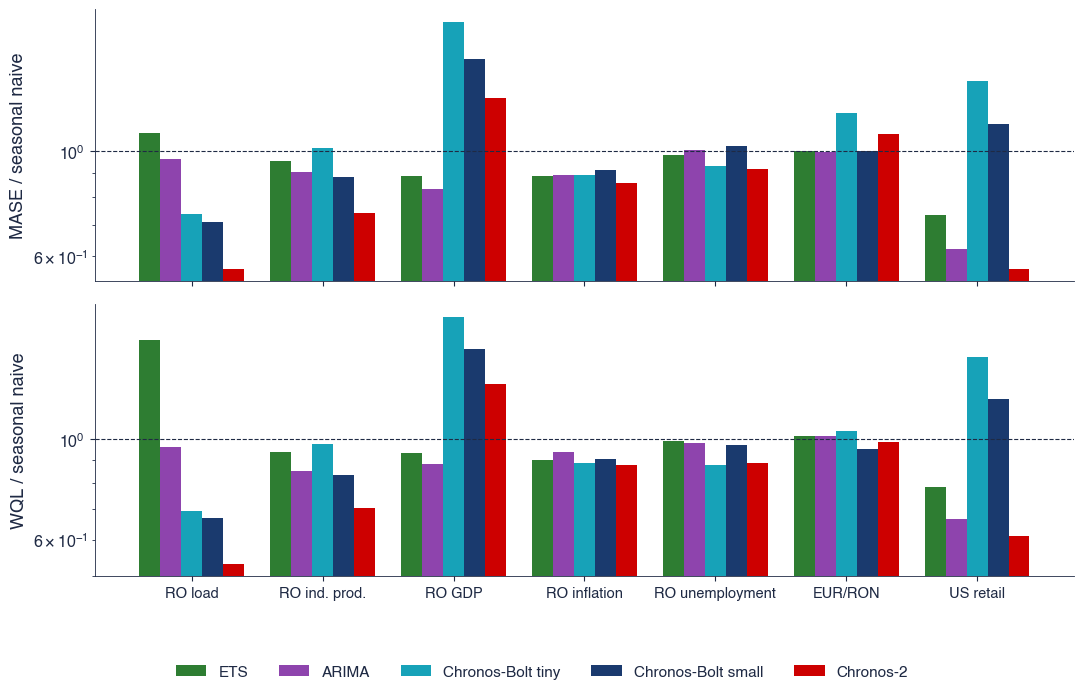

        ARIMA  Chronos-2  Chronos-Bolt small  Chronos-Bolt tiny    ETS  \
load    0.961      0.530               0.669              0.694  1.647   
ip      0.850      0.705               0.832              0.974  0.934   
gdp     0.880      1.323               1.580              1.858  0.930   
infl    0.936      0.874               0.902              0.884  0.897   
unemp   0.977      0.883               0.969              0.875  0.988   
eurron  1.015      0.986               0.951              1.039  1.012   
retail  0.666      0.611               1.226              1.515  0.782   

        Seasonal naive  
load               1.0  
ip                 1.0  
gdp                1.0  
infl               1.0  
unemp              1.0  
eurron             1.0  
retail             1.0  
geometric means: {'Seasonal naive': 1.0, 'ETS': 1.0, 'ARIMA': 0.89, 'Chronos-Bolt tiny': 1.063, 'Chronos-Bolt small': 0.984, 'Chronos-2': 0.811}


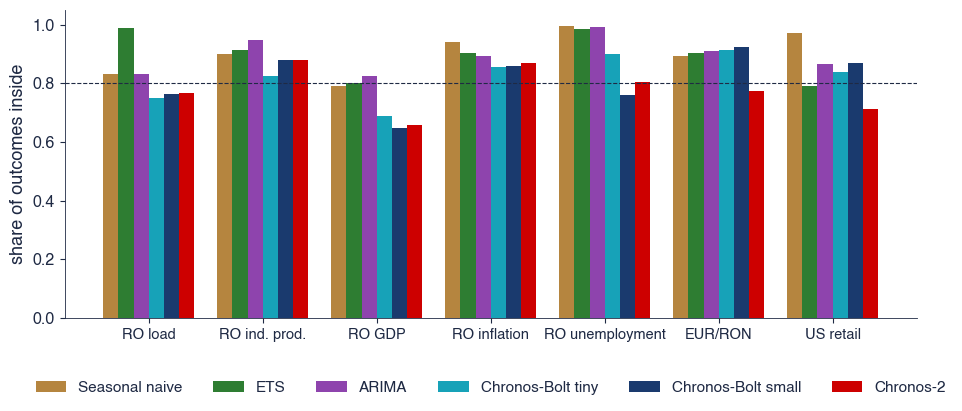

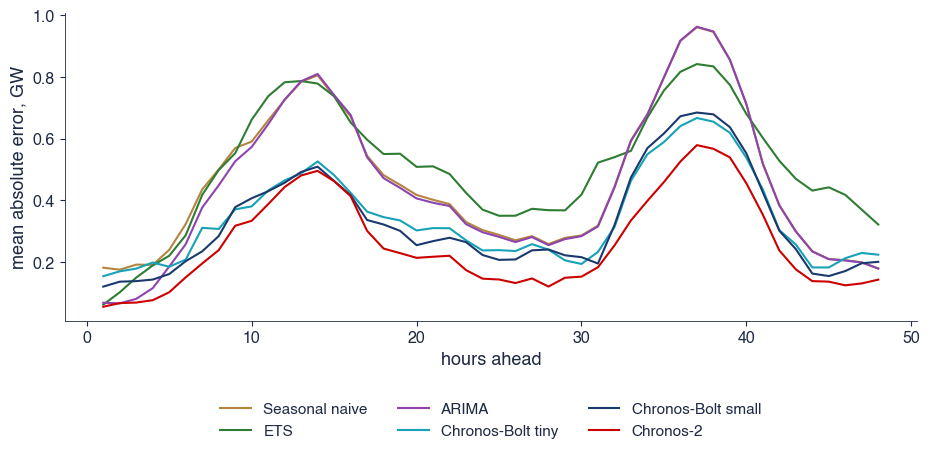

{'Seasonal naive': {'h1': 0.1815520833333333, 'h24': 0.30342708333333335, 'h48': 0.1791562499999998, 'all': 0.46268467881944436}, 'ETS': {'h1': 0.061801641132319195, 'h24': 0.36976105448337965, 'h48': 0.32144023632585417, 'all': 0.5084370488983299}, 'ARIMA': {'h1': 0.06784265889651797, 'h24': 0.29638458569213644, 'h48': 0.1786665175176879, 'all': 0.4461827275226488}, 'Chronos-Bolt tiny': {'h1': 0.15391313854853317, 'h24': 0.2374297191301982, 'h48': 0.2235446680386861, 'all': 0.3418486323455969}, 'Chronos-Bolt small': {'h1': 0.12015580892562867, 'h24': 0.22265124416351323, 'h48': 0.20048930009206134, 'all': 0.32910569939679574}, 'Chronos-2': {'h1': 0.05491642538706454, 'h24': 0.14595496495564778, 'h48': 0.14270667235056558, 'all': 0.262549758737286}}


In [10]:
def table_results(df):
    """Per series and model: MASE, WQL, coverage and the ratios to the seasonal naive; overall geometric means."""
    out = {}
    for k in EVAL_SERIES:
        sm = summarise(df[df.series == k])
        out[k] = {m: {c: float(sm.loc[m, c]) for c in sm.columns} for m in sm.index}
        out[k]['_n'] = int(df[(df.series == k) & (df.model == 'Seasonal naive')].shape[0])
    models = [m for m in MODELS if all(m in out[k] for k in EVAL_SERIES)]
    out['_gm'] = {m: {c: float(np.exp(np.mean([np.log(out[k][m][c]) for k in EVAL_SERIES]))) for c in ('rel_mase', 'rel_wql')}
                  for m in models}
    for m in models:
        out['_gm'][m]['cov80'] = float(np.mean([out[k][m]['cov80'] for k in EVAL_SERIES]))
        out['_gm'][m]['wins'] = int(sum(out[k][m]['rel_wql'] == min(out[k][x]['rel_wql'] for x in models) for k in EVAL_SERIES))
    return out


def bars(ax, R, col, models, ref=1.0, log=True):
    x = np.arange(len(EVAL_SERIES))
    w = 0.8 / len(models)
    for i, m in enumerate(models):
        ax.bar(x + (i - (len(models) - 1) / 2) * w, [R[k][m][col] for k in EVAL_SERIES], w, color=COLORS[m], label=m)
    ax.axhline(ref, color=st.DarkText, lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[k] for k in EVAL_SERIES], fontsize=10.5)
    if log:
        ax.set_yscale('log')


def fig_benchmark(df=None, save_it=True):
    """Relative MASE and relative WQL (ratio to the seasonal naive forecast, log scale) by series and model."""
    df = load_results() if df is None else df
    R = table_results(df)
    models = [m for m in MODELS if m != 'Seasonal naive' and m in R['_gm']]
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.6), sharex=True)
    bars(a1, R, 'rel_mase', models)
    a1.set_ylabel('MASE / seasonal naive')
    bars(a2, R, 'rel_wql', models)
    a2.set_ylabel('WQL / seasonal naive')
    st.fig_legend_bottom(fig, ncol=5, y=0.0)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    save('tsa_ch11_benchmark', save_it)
    return R


def fig_coverage(df=None, save_it=True):
    """Empirical coverage of the central 80% interval (10% and 90% quantiles) by series and model."""
    df = load_results() if df is None else df
    R = table_results(df)
    models = [m for m in MODELS if m in R['_gm']]
    fig, ax = plt.subplots(figsize=(11, 4))
    bars(ax, R, 'cov80', models, ref=0.8, log=False)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('share of outcomes inside')
    st.legend_outside_bottom(ax, ncol=6, y=-0.16)
    save('tsa_ch11_coverage', save_it)
    return {k: {m: R[k][m]['cov80'] for m in models} for k in EVAL_SERIES}


def fig_horizon(df=None, save_it=True, key='load'):
    """Mean absolute error by forecast step on Romanian load (48 hours ahead)."""
    df = load_results() if df is None else df
    d = df[df.series == key]
    fig, ax = plt.subplots(figsize=(11, 4))
    out = {}
    for m in [x for x in MODELS if x in set(d.model)]:
        e = np.array(d[d.model == m]['abs_err'].tolist())
        mae = e.mean(axis=0)
        ax.plot(np.arange(1, len(mae) + 1), mae, color=COLORS[m], lw=1.5, label=m)
        out[m] = {'h1': float(mae[0]), 'h24': float(mae[23]), 'h48': float(mae[-1]), 'all': float(mae.mean())}
    ax.set_xlabel('hours ahead')
    ax.set_ylabel('mean absolute error, GW')
    st.legend_outside_bottom(ax, ncol=3)
    save('tsa_ch11_horizon', save_it)
    return out


allr, infos = run_all(max_origins=24, save_csv=False)
R = fig_benchmark(allr, save_it=False)
print(pd.DataFrame({k: {m: round(R[k][m]['rel_wql'], 3) for m in R[k] if not m.startswith('_')} for k in EVAL_SERIES}).T)
print('geometric means:', {m: round(v['rel_wql'], 3) for m, v in R['_gm'].items()})
fig_coverage(allr, save_it=False)
print(fig_horizon(allr, save_it=False))

## 5. Context length, contamination and size

- Accuracy against the context length (12 weekly origins of the load); origins before and after the release of the weights; accuracy against the number of parameters.

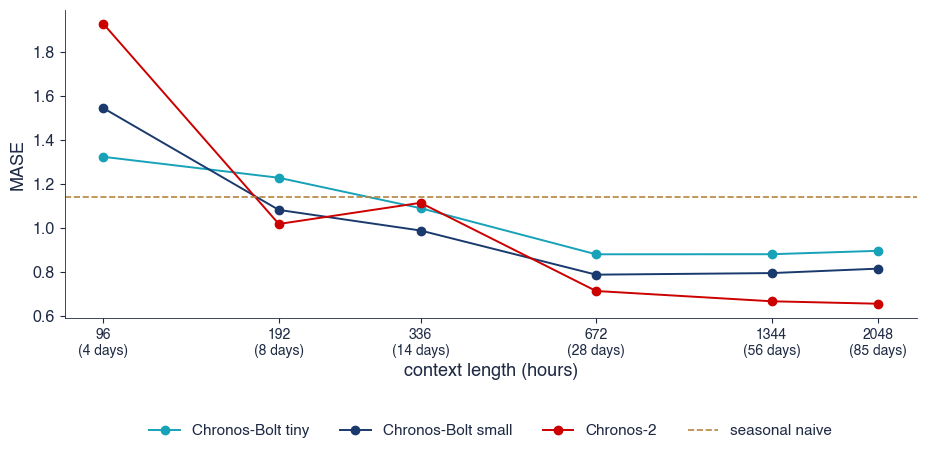

{'contexts': [96, 192, 336, 672, 1344, 2048], 'mase': {'Chronos-Bolt tiny': [1.3234184404411362, 1.2279402440544738, 1.089446443229958, 0.8795130054493532, 0.8798311425964297, 0.895339170815308], 'Chronos-Bolt small': [1.545175624988909, 1.0815870840365234, 0.9877551493305913, 0.786770681594052, 0.7939519881174523, 0.8142134090093264], 'Chronos-2': [1.9293191265301226, 1.0175416682697924, 1.113913933709868, 0.7124193157234399, 0.6655714236314428, 0.6543490988754882]}, 'naive': 1.1423430197820303, 'n': 12}


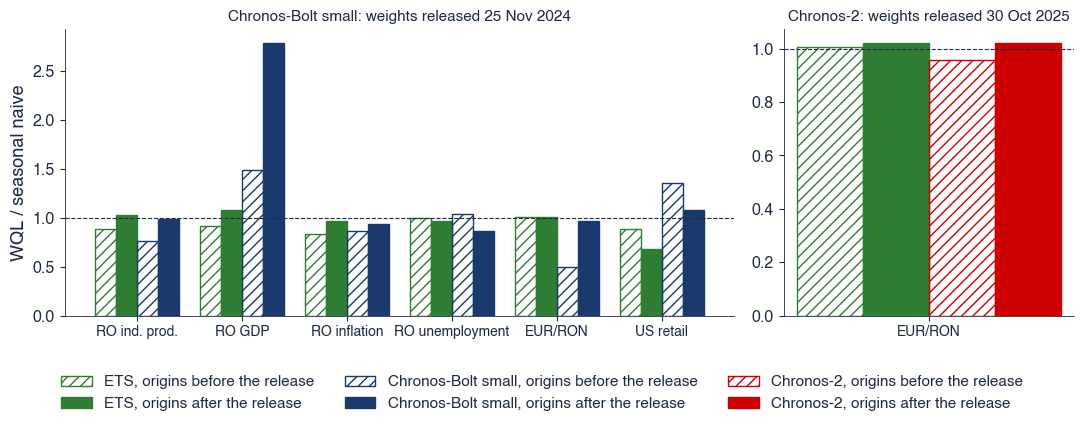

{'Chronos-Bolt small': {'ip': {'ETS|before': 0.8869947030911917, 'n|before': 15, 'ETS|after': 1.0310134743278254, 'n|after': 9, 'Chronos-Bolt small|before': 0.7575878793341329, 'Chronos-Bolt small|after': 0.9852455850163836}, 'gdp': {'ETS|before': 0.919079291096102, 'n|before': 21, 'ETS|after': 1.0838009091875884, 'n|after': 3, 'Chronos-Bolt small|before': 1.4911976847951094, 'Chronos-Bolt small|after': 2.787707395574449}, 'infl': {'ETS|before': 0.8371659187724718, 'n|before': 14, 'ETS|after': 0.9635464332908389, 'n|after': 10, 'Chronos-Bolt small|before': 0.8670326696246358, 'Chronos-Bolt small|after': 0.9405981457794487}, 'unemp': {'ETS|before': 1.0014316827968013, 'n|before': 14, 'ETS|after': 0.9662571592745015, 'n|after': 10, 'Chronos-Bolt small|before': 1.034081000812776, 'Chronos-Bolt small|after': 0.864458810541257}, 'eurron': {'ETS|before': 1.0080381261036975, 'n|before': 2, 'ETS|after': 1.0118657466344998, 'n|after': 22, 'Chronos-Bolt small|before': 0.5011877525421633, 'Chrono

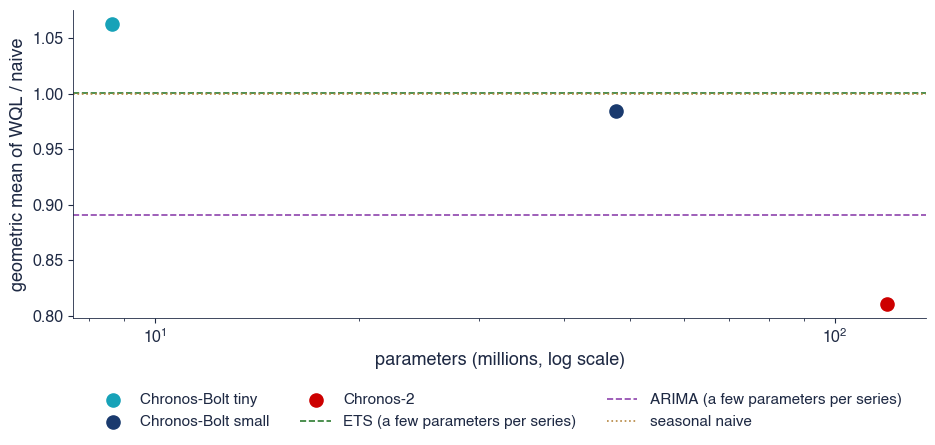

{'Chronos-Bolt tiny': {'params': 8652672, 'rel_wql': 1.0626544536803715}, 'Chronos-Bolt small': {'params': 47718016, 'rel_wql': 0.9843296497501638}, 'Chronos-2': {'params': 119477664, 'rel_wql': 0.8107701611677671}}


In [11]:
def fig_context(save_it=True, n_origins=26):
    """Zero-shot accuracy on Romanian load against the context length (last n_origins weekly origins)."""
    s = get_series('load')
    pos = origins_of('load', s)[-n_origins:]
    h = 48
    out = {}
    fig, ax = plt.subplots(figsize=(11, 4))
    for name in FM:
        if chronos_pipeline(name) is None:
            continue
        r = []
        for C in CONTEXTS:
            Q = fm_quantiles(name, [s.values[p - C:p] for p in pos], h)
            r.append(float(np.mean([mase(s.values[p:p + h], Q[i][:, 4], s.values[p - 2048:p], 168) for i, p in enumerate(pos)])))
        out[name] = r
        ax.plot(CONTEXTS, r, color=COLORS[name], marker='o', label=name)
    naive = float(np.mean([mase(s.values[p:p + h], snaive_q(s.values[p - 2048:p], h, 168)[:, 4], s.values[p - 2048:p], 168) for p in pos]))
    ax.axhline(naive, color=COLORS['Seasonal naive'], ls='--', lw=1.2, label='seasonal naive')
    ax.set_xscale('log', base=2)
    ax.set_xticks(CONTEXTS)
    ax.set_xticklabels([f'{c}\n({c / 24:.0f} days)' for c in CONTEXTS], fontsize=10)
    ax.set_xlabel('context length (hours)')
    ax.set_ylabel('MASE')
    st.legend_outside_bottom(ax, ncol=4, y=-0.3)
    save('tsa_ch11_context', save_it)
    return {'contexts': CONTEXTS, 'mase': out, 'naive': naive, 'n': len(pos)}


def fig_prepost(df=None, save_it=True):
    """Contamination check: WQL relative to the seasonal naive for origins before and after the release of the weights,
    for Chronos-Bolt small (25 November 2024) and Chronos-2 (30 October 2025), with ETS on the same origins; only the
    series whose test period spans the release date."""
    df = load_results() if df is None else df
    out = {}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={'width_ratios': [3, 1.3]})
    for ax, fm in zip(axes, ('Chronos-Bolt small', 'Chronos-2')):
        cut = pd.Timestamp(RELEASE[fm])
        keys = [k for k in EVAL_SERIES if (df[df.series == k].origin < cut).any() and (df[df.series == k].origin >= cut).any()]
        x = np.arange(len(keys))
        for j, (m, part) in enumerate([(m, p) for m in ('ETS', fm) for p in ('before', 'after')]):
            vals = []
            for k in keys:
                d = df[df.series == k]
                d = d[d.origin < cut] if part == 'before' else d[d.origin >= cut]
                sm = summarise(d)
                vals.append(float(sm.loc[m, 'rel_wql']) if m in sm.index else np.nan)
                out.setdefault(fm, {}).setdefault(k, {})[f'{m}|{part}'] = vals[-1]
                out[fm][k][f'n|{part}'] = int((d.model == 'Seasonal naive').sum())
            ax.bar(x + (j - 1.5) * 0.2, vals, 0.2, facecolor='none' if part == 'before' else COLORS[m],
                   edgecolor=COLORS[m], hatch='///' if part == 'before' else None, lw=1,
                   label=f'{m}, origins {part} the release' if fm == 'Chronos-Bolt small' or m != 'ETS' else '_')
        ax.axhline(1, color=st.DarkText, lw=0.8, ls='--')
        ax.set_xticks(x)
        ax.set_xticklabels([SHORT[k] for k in keys], fontsize=10)
        ax.set_title(f'{fm}: weights released {cut.day} {cut.strftime("%b %Y")}', fontsize=11)
    axes[0].set_ylabel('WQL / seasonal naive')
    st.fig_legend_bottom(fig, ncol=3, y=0.12)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    save('tsa_ch11_prepost', save_it)
    return out


def fig_size(df=None, infos=None, save_it=True):
    """Accuracy (geometric mean of the relative WQL over the seven series) against the number of parameters."""
    df = load_results() if df is None else df
    R = table_results(df)
    out = {}
    fig, ax = plt.subplots(figsize=(11, 4))
    for m in FM:
        npar = n_parameters(m)
        if npar is None or m not in R['_gm']:
            continue
        out[m] = {'params': npar, 'rel_wql': R['_gm'][m]['rel_wql']}
        ax.scatter(npar / 1e6, R['_gm'][m]['rel_wql'], s=90, color=COLORS[m], label=m, zorder=3)
    for m in ('ETS', 'ARIMA'):
        if m in R['_gm']:
            ax.axhline(R['_gm'][m]['rel_wql'], color=COLORS[m], ls='--', lw=1.2, label=f'{m} (a few parameters per series)')
    ax.axhline(1, color=COLORS['Seasonal naive'], ls=':', lw=1.2, label='seasonal naive')
    ax.set_xscale('log')
    ax.set_xlabel('parameters (millions, log scale)')
    ax.set_ylabel('geometric mean of WQL / naive')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('tsa_ch11_size', save_it)
    return out


print(fig_context(save_it=False, n_origins=12))
print(fig_prepost(allr, save_it=False))
print(fig_size(allr, save_it=False))

## 6. Exercises for self-study

1. Replace Chronos-Bolt small with Chronos-Bolt tiny in `fig_fan_load`. Report the MASE and the coverage of the 80% interval. Is the smaller model much worse?
2. Add a series of your choice (for example `read_fred('INDPRO')` or a Eurostat series of another country) to `EVAL_SERIES` and run `backtest` on it. Report the relative WQL of every model.
3. Shorten the context of the monthly series to 36 months. Does the ranking of the models change?
4. Interpretation: in one sentence, for which of the seven series would you use a foundation model in practice, and why?